# TP — Régression linéaire simple : la croissance du COVID-19

En mars 2020, les journaux parlaient tous les soirs de « croissance exponentielle » et
de « temps de doublement ». Dans ce TP, vous allez retrouver ces chiffres vous-mêmes,
à partir des données réelles de l'université Johns Hopkins, avec la formule que vous
venez de démontrer en cours.

**Le fil du TP**

1. On charge les cas cumulés en France sur les quatre premières semaines de l'épidémie.
2. On sépare les données en **train** et **test**.
3. On implémente à la main, en numpy, la solution $\hat\beta_0, \hat\beta_1$ du cours.
4. On refait la même chose avec `scikit-learn`, et on vérifie qu'on trouve la même chose.
5. On trace le graphe **prédictions contre réalité** — et on découvre que la droite ne
   convient pas.
6. On essaie alors un modèle **exponentiel**, qui se ramène à la même régression simple
   sur des variables transformées. On en tire le **temps de doublement**.

**Ce que vous devez compléter** est signalé par `# TODO`. Chaque fonction est suivie
d'une cellule de test : tant qu'elle lève une erreur, ce n'est pas bon. Le chargement
des données et les graphiques vous sont **fournis**.

---
## 0. Mise en place

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

CHEMIN = "data/covid_jhu_confirmed.csv"   # adaptez si besoin

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.2.6 | pandas 2.3.2


---
## 1. Les données

Le fichier vient du dépôt **Johns Hopkins CSSE**, qui a recensé jour par jour les cas
confirmés de COVID-19 dans le monde entier. Il est au format « large » : une ligne par
région, une **colonne par date**.

Les deux fonctions ci-dessous vous sont fournies :

- `charger()` regroupe les régions par pays et convertit les noms de colonnes en dates ;
- `fenetre()` extrait, pour un pays, les `n_jours` qui suivent le jour où le pays a
  dépassé `seuil` cas. On repère ainsi le **début de l'épidémie** dans chaque pays, ce
  qui permettra de les comparer entre eux.

In [45]:
def charger(chemin=CHEMIN):
    """Charge le fichier JHU et renvoie un tableau pays x dates de cas cumules."""
    d = pd.read_csv(chemin)
    d = d.groupby("Country/Region").sum(numeric_only=True).drop(columns=["Lat", "Long"])
    d.columns = pd.to_datetime(d.columns, format="%m/%d/%y")
    return d


def fenetre(table, pays, seuil=50, n_jours=28):
    """Renvoie (jours, cas, dates) pour les n_jours suivant le franchissement du seuil.

    `jours` vaut 0, 1, 2, ... : c'est notre variable explicative x.
    `cas` est le nombre de cas cumules : c'est notre variable reponse y.
    """
    cumul = table.loc[pays].to_numpy(float)
    i0 = int(np.argmax(cumul >= seuil))
    cas = cumul[i0:i0 + n_jours]
    jours = np.arange(len(cas), dtype=float)
    return jours, cas, table.columns[i0:i0 + n_jours]

In [46]:
table = charger()
print("pays disponibles :", len(table), "| periode :",
      table.columns[0].date(), "->", table.columns[-1].date())

PAYS = "France"
x, y, dates = fenetre(table, PAYS, seuil=50, n_jours=28)

print(f"\n{PAYS} : du {dates[0].date()} au {dates[-1].date()}")
print(f"   {len(x)} jours, de {int(y[0])} a {int(y[-1])} cas cumules")

pays disponibles : 201 | periode : 2020-01-22 -> 2023-03-09

France : du 2020-02-28 au 2020-03-26
   28 jours, de 57 a 29252 cas cumules


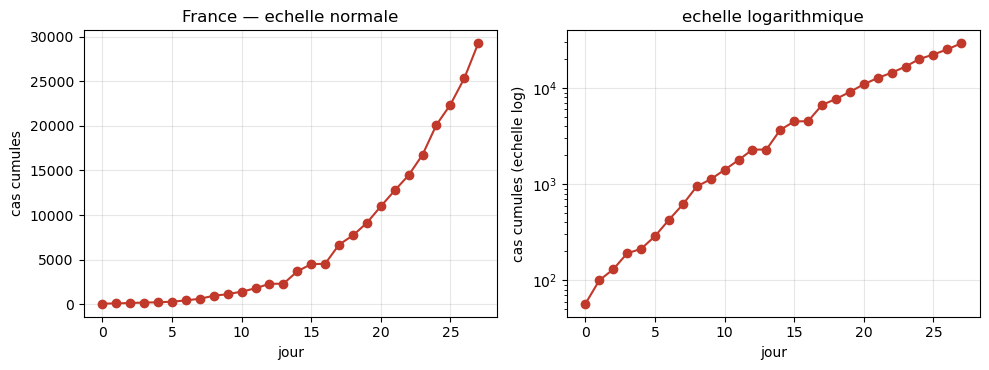

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(x, y, "o-", color="#c0392b")
ax[0].set_xlabel("jour"); ax[0].set_ylabel("cas cumules"); ax[0].set_title(f"{PAYS} — echelle normale")
ax[1].semilogy(x, y, "o-", color="#c0392b")
ax[1].set_xlabel("jour"); ax[1].set_ylabel("cas cumules (echelle log)")
ax[1].set_title("echelle logarithmique")
for a in ax: a.grid(alpha=.3)
plt.tight_layout()

> **Question 1.** Regardez les deux graphiques. À gauche, la courbe s'envole. À droite,
> en échelle logarithmique, elle devient presque une **droite**. Que vous dit ce second
> graphique sur la nature de la croissance ? Gardez la réponse de côté, on y reviendra
> en partie 7.

---
## 2. Train / test

On met de côté 30 % des jours, choisis au hasard : le modèle ne les verra **jamais**
pendant l'ajustement, et ne servira qu'à mesurer sa qualité.

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)
print(f"train : {len(x_train)} jours | test : {len(x_test)} jours")

train : 19 jours | test : 9 jours


---
## 3. La formule du cours, à la main

Vous avez démontré en cours qu'en annulant les deux dérivées partielles de la RSS on
obtient

$$
\hat\beta_1 = \frac{\sum_{i}(x_i - \bar x)(y_i - \bar y)}{\sum_i (x_i - \bar x)^2}
\qquad\text{et}\qquad
\hat\beta_0 = \bar y - \hat\beta_1 \bar x .
$$

**À vous.** Traduisez ces deux formules en numpy. Pas de boucle `for` : utilisez
`.mean()` et `.sum()` sur les tableaux.

In [49]:
def estimer_droite(x, y):
    """Estime les coefficients de la droite des moindres carres.

    Args:
        x, y (np.ndarray): les donnees d'entrainement

    Returns:
        (b0, b1) : l'ordonnee a l'origine et la pente
    """
    xb, yb = x.mean(), y.mean()
    b1 = ((x - xb) * (y - yb)).sum() / ((x - xb) ** 2).sum()
    b0 = yb - b1 * xb
    return b0, b1

In [50]:
# --- test ---
xt = np.array([0., 1., 2., 3.])
yt = np.array([1., 3., 5., 7.])              # exactement y = 1 + 2x
b0t, b1t = estimer_droite(xt, yt)
assert np.isclose(b0t, 1.0) and np.isclose(b1t, 2.0), (b0t, b1t)

b0, b1 = estimer_droite(x_train, y_train)
print(f"b0 = {b0:10.1f}    b1 = {b1:8.1f}")
print("estimer_droite : OK")

b0 =    -5480.0    b1 =    975.4
estimer_droite : OK


> **Question 2.** Regardez $\hat\beta_0$. Il est **négatif**. Or $\hat\beta_0$ est le
> nombre de cas prédit au jour 0. Que penser d'un modèle qui prédit un nombre de cas
> négatif ? C'est un premier indice que la droite n'est pas la bonne forme.

---
## 4. Prédire, et mesurer

Deux fonctions à écrire.

`predire` applique le modèle : $\hat y = \hat\beta_0 + \hat\beta_1 x$.

`r2` calcule le coefficient de détermination
$$
R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}.
$$
Le numérateur est l'erreur de **votre** modèle, le dénominateur celle du modèle le plus
bête possible : prédire toujours la moyenne $\bar y$. Donc $R^2 = 1$ veut dire parfait,
$R^2 = 0$ veut dire « pas mieux que la moyenne », et $R^2 < 0$ veut dire **pire que la
moyenne**.

In [51]:
def predire(b0, b1, x):
    """Applique le modele lineaire aux points x."""
    return b0 + b1 * x


def r2(y_vrai, y_pred):
    """Coefficient de determination."""
    return 1 - ((y_vrai - y_pred) ** 2).sum() / ((y_vrai - y_vrai.mean()) ** 2).sum()

In [52]:
# --- test ---
assert np.allclose(predire(1., 2., np.array([0., 1., 2.])), [1., 3., 5.])
assert np.isclose(r2(np.array([1., 2., 3.]), np.array([1., 2., 3.])), 1.0)
assert np.isclose(r2(np.array([1., 2., 3.]), np.array([2., 2., 2.])), 0.0)

y_pred_lin = predire(b0, b1, x_test)
R2_lin = r2(y_test, y_pred_lin)
print(f"R2 du modele lineaire sur le test : {R2_lin:.3f}")

R2 du modele lineaire sur le test : 0.731


---
## 5. La même chose avec scikit-learn

En pratique, on n'écrit pas la formule soi-même. Voici la version `sklearn`.

Attention à un détail : `sklearn` attend une matrice `X` de forme `(n_observations,
n_variables)`, et non un vecteur. Comme on n'a qu'une seule variable explicative, il
faut transformer `x` de la forme `(n,)` à la forme `(n, 1)`, par exemple avec
`x.reshape(-1, 1)`.

**À vous.** Ajustez une `LinearRegression` et récupérez ses coefficients — ce sont
`modele.intercept_` et `modele.coef_[0]`.

In [53]:
def ajuster_sklearn(x, y):
    """Ajuste une LinearRegression de sklearn.

    Returns:
        (b0, b1) : les memes deux nombres que estimer_droite
    """
    modele = LinearRegression()
    modele.fit(x.reshape(-1, 1), y)
    return modele.intercept_, modele.coef_[0]

In [54]:
# --- test : sklearn doit retrouver EXACTEMENT vos coefficients ---
b0_sk, b1_sk = ajuster_sklearn(x_train, y_train)
print(f"a la main : b0 = {b0:12.4f}   b1 = {b1:10.4f}")
print(f"sklearn   : b0 = {b0_sk:12.4f}   b1 = {b1_sk:10.4f}")
print(f"ecart     :      {abs(b0-b0_sk):12.2e}        {abs(b1-b1_sk):10.2e}")
assert np.allclose([b0, b1], [b0_sk, b1_sk]), "les deux methodes doivent coincider"
print("\nsklearn resout le meme probleme que votre formule : OK")

a la main : b0 =   -5480.0310   b1 =   975.3624
sklearn   : b0 =   -5480.0310   b1 =   975.3624
ecart     :          7.28e-12          4.55e-13

sklearn resout le meme probleme que votre formule : OK


---
## 6. Prédictions contre réalité

Le $R^2$ résume la qualité du modèle en **un seul nombre**, ce qui cache beaucoup de
choses. Le graphe ci-dessous est plus parlant : on place chaque jour du test set en
abscisse par sa vraie valeur, en ordonnée par la valeur prédite.

**Si le modèle était parfait, tous les points tomberaient sur la diagonale** $y = x$.
L'écart vertical d'un point à la diagonale est exactement son erreur de prédiction.

In [55]:
def graphe_diagonal(y_vrai, y_pred, titre="", ax=None, couleur="#c0392b"):
    """Nuage predictions vs realite, avec la diagonale de reference. Fourni."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 4.2))
    lo = min(y_vrai.min(), y_pred.min())
    hi = max(y_vrai.max(), y_pred.max())
    marge = 0.05 * (hi - lo)
    ax.plot([lo - marge, hi + marge], [lo - marge, hi + marge], "--", color="gray",
            lw=1, label="modele parfait")
    ax.scatter(y_vrai, y_pred, s=55, color=couleur, zorder=3, edgecolor="white")
    for v, p in zip(y_vrai, y_pred):            # le trait vertical = l'erreur
        ax.plot([v, v], [v, p], color=couleur, alpha=.35, lw=1)
    ax.set_xlabel("cas reellement observes")
    ax.set_ylabel("cas predits")
    ax.set_title(titre, fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=.3)
    return ax

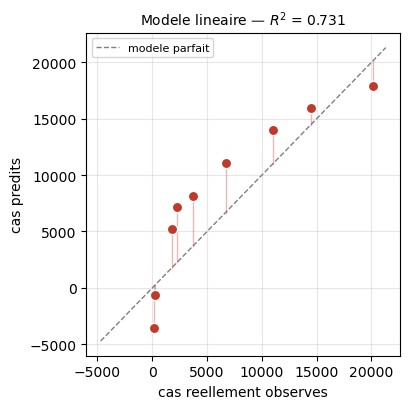

In [56]:
graphe_diagonal(y_test, y_pred_lin, f"Modele lineaire — $R^2$ = {R2_lin:.3f}")
plt.tight_layout()

> **Question 3.** Les points ne sont pas dispersés **au hasard** autour de la
> diagonale : ils dessinent une courbe. Le modèle sous-estime dans certaines zones et
> surestime dans d'autres, de façon **systématique**. Décrivez ce que vous voyez.
>
> Un modèle dont les erreurs sont structurées comme ça, ce n'est pas un modèle bruité :
> c'est un modèle qui a la **mauvaise forme**.

---
## 7. Le modèle exponentiel

Une épidémie qui démarre ne croît pas linéairement : chaque malade en contamine un
nombre fixe d'autres, donc le nombre de cas est **multiplié** par un facteur constant à
chaque intervalle de temps. Le modèle naturel est

$$
y = a \, e^{b x}.
$$

Il n'est pas linéaire — mais il le devient si l'on prend le logarithme des deux côtés :

$$
\ln y = \underbrace{\ln a}_{\beta_0} + \underbrace{b}_{\beta_1} \, x .
$$

C'est **exactement** une régression linéaire simple, mais sur $(x, \ln y)$ au lieu de
$(x, y)$. Vous n'avez donc aucune nouvelle formule à écrire : il suffit d'appeler
`estimer_droite` sur les données transformées, puis de revenir à l'échelle des cas avec
l'exponentielle.

**À vous.**

In [57]:
def estimer_expo(x, y):
    """Ajuste le modele y = a * exp(b * x) par regression lineaire sur (x, ln y).

    Returns:
        (a, b) : le coefficient multiplicatif et le taux de croissance
    """
    ln_a, b = estimer_droite(x, np.log(y))
    return np.exp(ln_a), b


def predire_expo(a, b, x):
    """Applique le modele exponentiel."""
    return a * np.exp(b * x)

In [58]:
# --- test ---
xt = np.array([0., 1., 2., 3.])
yt = 5.0 * np.exp(0.7 * xt)                   # exactement y = 5 e^{0.7x}
at, bt = estimer_expo(xt, yt)
assert np.isclose(at, 5.0) and np.isclose(bt, 0.7), (at, bt)

a, b = estimer_expo(x_train, y_train)
y_pred_exp = predire_expo(a, b, x_test)
R2_exp = r2(y_test, y_pred_exp)
print(f"a = {a:.1f}   b = {b:.4f}")
print(f"\nR2 lineaire    : {R2_lin:.3f}")
print(f"R2 exponentiel : {R2_exp:.3f}")

a = 111.2   b = 0.2224

R2 lineaire    : 0.731
R2 exponentiel : 0.959


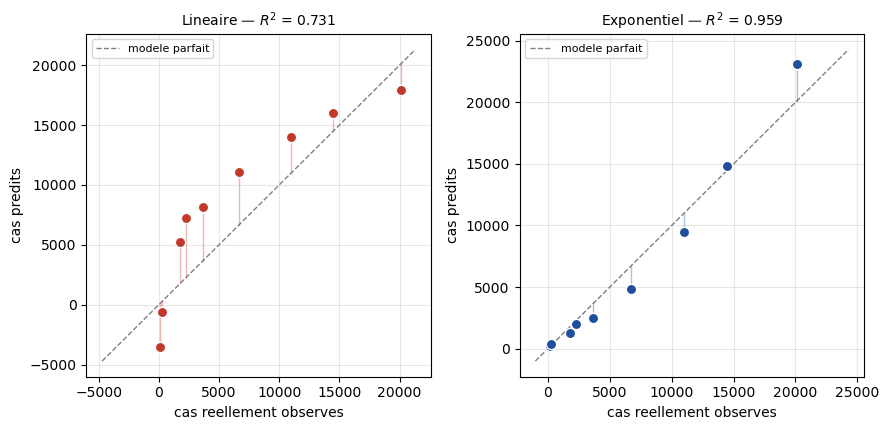

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
graphe_diagonal(y_test, y_pred_lin, f"Lineaire — $R^2$ = {R2_lin:.3f}", axes[0], "#c0392b")
graphe_diagonal(y_test, y_pred_exp, f"Exponentiel — $R^2$ = {R2_exp:.3f}", axes[1], "#1f4e9c")
plt.tight_layout()

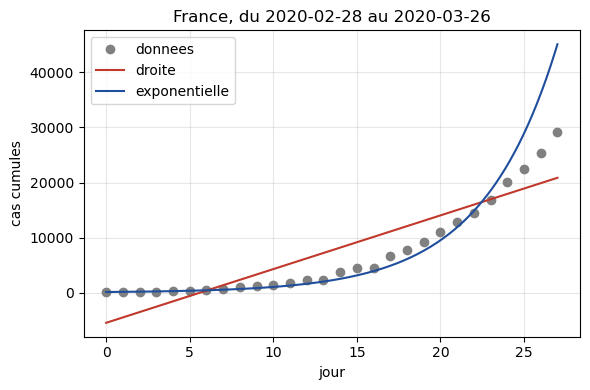

In [60]:
# les deux modeles sur la courbe complete
xx = np.linspace(x.min(), x.max(), 200)
plt.figure(figsize=(6, 4))
plt.plot(x, y, "o", color="gray", label="donnees")
plt.plot(xx, predire(b0, b1, xx), color="#c0392b", label="droite")
plt.plot(xx, predire_expo(a, b, xx), color="#1f4e9c", label="exponentielle")
plt.xlabel("jour"); plt.ylabel("cas cumules"); plt.legend(); plt.grid(alpha=.3)
plt.title(f"{PAYS}, du {dates[0].date()} au {dates[-1].date()}")
plt.tight_layout()

---
## 8. Le temps de doublement

Le coefficient $b$ n'est pas qu'un nombre dans une formule : il a un sens que tout le
monde a entendu au journal télévisé. Si $y = a\,e^{bx}$, le temps $T$ au bout duquel le
nombre de cas **double** vérifie $e^{bT} = 2$, donc

$$
T = \frac{\ln 2}{b}.
$$

**À vous.**

In [61]:
def temps_de_doublement(b):
    """Renvoie le nombre de jours au bout duquel le nombre de cas double."""
    return np.log(2) / b

In [62]:
# --- test ---
assert np.isclose(temps_de_doublement(np.log(2)), 1.0)   # si b = ln2, on double en 1 jour
print(f"{PAYS} : temps de doublement = {temps_de_doublement(b):.2f} jours\n")

print("--- comparaison entre pays (seuil 50, 28 premiers jours) ---")
for p in ["France", "Italy", "Spain", "Germany", "United Kingdom", "US", "India", "Korea, South"]:
    xp, yp, _ = fenetre(table, p, seuil=50, n_jours=28)
    if yp.min() <= 0:
        continue
    _, bp = estimer_expo(xp, yp)
    print(f"   {p:18s} {temps_de_doublement(bp):5.2f} jours")

France : temps de doublement = 3.12 jours

--- comparaison entre pays (seuil 50, 28 premiers jours) ---
   France              3.08 jours
   Italy               3.12 jours
   Spain               2.68 jours
   Germany             2.89 jours
   United Kingdom      3.14 jours
   US                  2.33 jours
   India               4.19 jours
   Korea, South        5.19 jours


> **Question 4.** Le temps de doublement en France début mars 2020 est d'environ trois
> jours. Vérifiez ce que cela implique : en partant de 100 cas, combien en a-t-on au
> bout de 30 jours ? Comparez à ce que prédit la droite.
>
> **Question 5.** La Corée du Sud se détache nettement des pays européens. Cherchez ce
> que ce pays a fait en février-mars 2020 que les autres n'ont pas fait. Le coefficient
> $b$ n'est pas une fatalité : c'est la trace des décisions prises.

---
## 9. Quand le modèle cesse-t-il d'être valable ?

L'exponentielle décrit très bien les 28 premiers jours. Mais une épidémie ne croît pas
indéfiniment : les gens changent de comportement, des mesures sont prises. Regardons
**quand** le modèle décroche.

Plutôt que de réajuster sur des fenêtres de plus en plus longues — on verra en §11
pourquoi c'est une mauvaise idée — on mesure le **temps de doublement sur une fenêtre
glissante de 7 jours**. S'il reste constant, la croissance est bien exponentielle. S'il
augmente, c'est que l'épidémie ralentit.

In [63]:
def doublement_glissant(table, pays, seuil=50, largeur=7, n_fenetres=12, pas=5):
    """Temps de doublement estime sur une fenetre glissante de `largeur` jours. Fourni."""
    cumul = table.loc[pays].to_numpy(float)
    i0 = int(np.argmax(cumul >= seuil))
    lignes = []
    for k in range(n_fenetres):
        d = i0 + k * pas
        y = cumul[d:d + largeur]
        if len(y) < largeur or y.min() <= 0:
            break
        if (np.diff(y) < 0).any():      # cumul qui baisse : donnees incoherentes, on arrete
            return lignes, table.columns[d]
        
        _, bk = estimer_expo(np.arange(largeur, dtype=float), y)
        lignes.append((table.columns[d], table.columns[d + largeur - 1],
                       temps_de_doublement(bk) if bk > 0 else np.inf))
    return lignes, None


lignes, arret = doublement_glissant(table, PAYS)
print(f"{'fenetre de 7 jours':>28s}   {'T doublement':>13s}")
for deb, fin, t2 in lignes:
    if np.isfinite(t2):
        print(f"  {deb.date()} -> {fin.date()}   {t2:8.2f} j  " + "#" * min(int(t2), 45))
    else:
        print(f"  {deb.date()} -> {fin.date()}   {'infini':>8s}    (les cas ne doublent plus)")

if arret is not None:
    print(f"\n  arret : a partir de la fenetre du {arret.date()}, le cumul DIMINUE")
    print("  certains jours, ce qui est impossible. Voir la cellule suivante.")

          fenetre de 7 jours    T doublement
  2020-02-28 -> 2020-03-05       2.25 j  ##
  2020-03-04 -> 2020-03-10       2.29 j  ##
  2020-03-09 -> 2020-03-15       3.33 j  ###
  2020-03-14 -> 2020-03-20       3.73 j  ###
  2020-03-19 -> 2020-03-25       4.90 j  ####
  2020-03-24 -> 2020-03-30       5.96 j  #####

  arret : a partir de la fenetre du 2020-03-29, le cumul DIMINUE
  certains jours, ce qui est impossible. Voir la cellule suivante.


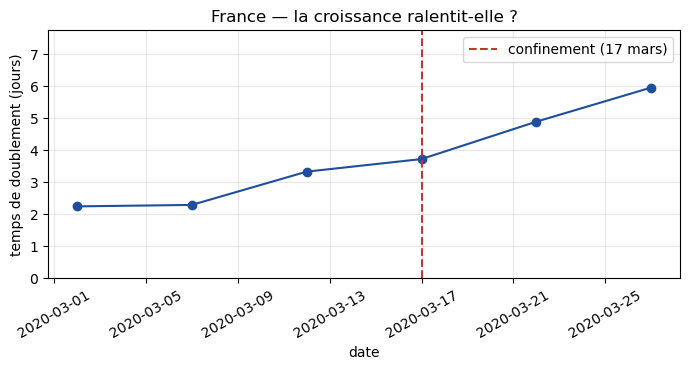

In [64]:
finies = [(deb + (fin - deb) / 2, t2) for deb, fin, t2 in lignes if np.isfinite(t2)]
milieux = [m for m, _ in finies]
valeurs = [t2 for _, t2 in finies]
plt.figure(figsize=(7, 3.8))
plt.plot(milieux, valeurs, "o-", color="#1f4e9c")
plt.axvline(pd.Timestamp("2020-03-17"), color="#c0392b", ls="--", label="confinement (17 mars)")
plt.ylim(0, max(valeurs) * 1.3)
plt.ylabel("temps de doublement (jours)"); plt.xlabel("date")
plt.title(f"{PAYS} — la croissance ralentit-elle ?")
plt.legend(); plt.grid(alpha=.3); plt.xticks(rotation=30)
plt.tight_layout()

---
### Un détour obligatoire : les données sont-elles fiables ?

La boucle ci-dessus s'est arrêtée d'elle-même. La raison mérite qu'on s'y attarde, parce
qu'elle est plus instructive que le modèle lui-même : **le nombre de cas cumulés
diminue** certains jours. C'est logiquement impossible — un cumul ne peut que croître.

Vérifions-le directement.

In [66]:
cumul_fr = table.loc[PAYS].to_numpy(float)
variations = np.diff(cumul_fr)
jours_ko = np.where(variations < 0)[0]

print(f"{PAYS} : le cumul diminue {len(jours_ko)} jours sur toute la serie.\n")
print("les 5 plus fortes baisses :")
for i in jours_ko[np.argsort(variations[jours_ko])][:5]:
    print(f"   {table.columns[i+1].date()} : {variations[i]:+12,.0f} cas")

print("\nautour du 4 avril 2020 :")
deb = int(np.argmax(table.columns >= pd.Timestamp("2020-04-01")))
for i in range(deb, deb + 12):
    v = cumul_fr[i] - cumul_fr[i-1]
    if v < 0:
        alerte = "   <-- impossible"
    elif v > 20000:
        alerte = "   <-- rattrapage massif"
    else:
        alerte = ""
    print(f"   {table.columns[i].date()} : {cumul_fr[i]:10,.0f}  ({v:+9,.0f}){alerte}")

France : le cumul diminue 12 jours sur toute la serie.

les 5 plus fortes baisses :
   2021-05-20 :     -348,840 cas
   2020-11-04 :      -46,121 cas
   2022-05-23 :      -29,635 cas
   2020-04-04 :      -17,076 cas
   2020-04-07 :       -3,489 cas

autour du 4 avril 2020 :
   2020-04-01 :     57,125  (   +4,844)
   2020-04-02 :     59,227  (   +2,102)
   2020-04-03 :     64,452  (   +5,225)
   2020-04-04 :     47,376  (  -17,076)   <-- impossible
   2020-04-05 :     48,225  (     +849)
   2020-04-06 :     50,884  (   +2,659)
   2020-04-07 :     47,395  (   -3,489)   <-- impossible
   2020-04-08 :     51,250  (   +3,855)
   2020-04-09 :     55,034  (   +3,784)
   2020-04-10 :     56,600  (   +1,566)
   2020-04-11 :     58,045  (   +1,445)
   2020-04-12 :    108,792  (  +50,747)   <-- rattrapage massif


> **Question 6.** Sur les fenêtres exploitables, le temps de doublement passe d'environ
> 2,3 jours fin février à près de 6 jours fin mars : il a plus que doublé en un mois.
> À partir de quelle date commence-t-il clairement à monter ?
>
> Attention au piège : la hausse démarre **avant** le confinement du 17 mars. Deux
> raisons, qu'il faut avoir en tête pour interpréter honnêtement ces données :
>
> - le confinement n'est pas la première mesure — les rassemblements ont été interdits
>   le 13 mars, les écoles fermées le 16 ;
> - surtout, un cas **confirmé** aujourd'hui a été contaminé une à deux semaines plus
>   tôt : contamination, incubation, symptômes, test, déclaration. Les courbes de cas
>   sont en retard sur la réalité épidémique.
>
> Autrement dit, on ne peut pas lire une date de décision directement sur la courbe,
> mais on voit très bien que **quelque chose a changé** au cours du mois de mars.
>
> **Question 6 bis.** Le 12 avril 2020, le cumul français bondit de plus de 50 000 cas
> en une journée : c'est le jour où les cas en EHPAD ont été intégrés au décompte.
> Un modèle, si bon soit-il, ne peut rien contre une donnée qui change de définition en
> cours de route. Que faudrait-il faire avant de modéliser quoi que ce soit sur la
> période d'avril ?

---
## 10. Le prix d'une extrapolation

Reprenons le modèle ajusté sur les 28 premiers jours seulement, et demandons-lui de
prédire la suite — ce que faisaient beaucoup de gens en mars 2020.

In [67]:
a28, b28 = estimer_expo(x, y)           # ajustement sur toute la fenetre de 28 jours
cumul_total = table.loc[PAYS].to_numpy(float)
i0 = int(np.argmax(cumul_total >= 50))

print(f"{'jour':>5s} {'date':>12s} {'cas reels':>14s} {'cas predits':>18s} {'rapport':>10s}")
for k in (27, 34, 41, 48, 62, 76, 104):
    if i0 + k >= len(cumul_total):
        break
    reel = cumul_total[i0 + k]
    pred = predire_expo(a28, b28, k)
    print(f"{k:5d} {str(table.columns[i0+k].date()):>12s} {reel:14,.0f} {pred:18,.0f} {pred/reel:9.1f}x")

pred100 = predire_expo(a28, b28, 100)
print(f"\nAu jour 100, le modele predit {pred100:,.0f} cas.")
print(f"La France compte 68 millions d'habitants : le modele annonce donc")
print(f"{pred100/68e6:,.0f} fois la population du pays.")

 jour         date      cas reels        cas predits    rapport
   27   2020-03-26         29,252             47,741       1.6x
   34   2020-04-02         59,227            230,287       3.9x
   41   2020-04-09         55,034          1,110,839      20.2x
   48   2020-04-16        145,166          5,358,369      36.9x
   62   2020-04-30        168,861        124,679,593     738.4x
   76   2020-05-14        180,635      2,901,069,684   16060.4x
  104   2020-06-11        195,179  1,570,665,589,077 8047308.3x

Au jour 100, le modele predit 639,116,568,649 cas.
La France compte 68 millions d'habitants : le modele annonce donc
9,399 fois la population du pays.


> **Question 7.** Le modèle qui collait si bien sur 28 jours prédit, 100 jours plus
> tard, près de **10 000 fois la population française**. Un modèle très bien ajusté sur
> son domaine peut devenir absurde juste à côté.
>
> Que faudrait-il changer au modèle pour qu'il reste raisonnable ? (Indice : que se
> passe-t-il quand presque tout le monde a déjà été contaminé ? Cherchez « modèle
> logistique ».)

---
## 11. Un avertissement sur l'évaluation

Notre test set ne contient que 9 jours. Est-ce suffisant pour comparer deux modèles ?
La cellule suivante refait l'expérience avec 40 découpages train/test différents et
regarde comment varie le $R^2$ du modèle exponentiel.

In [68]:
for n in (28, 34, 40):
    xn, yn, _ = fenetre(table, PAYS, seuil=50, n_jours=n)
    scores = []
    for graine in range(40):
        xa, xb_, ya, yb_ = train_test_split(xn, yn, test_size=0.3, random_state=graine)
        an, bn = estimer_expo(xa, ya)
        scores.append(r2(yb_, predire_expo(an, bn, xb_)))
    s = np.array(scores)
    print(f"fenetre {n:3d} j : R2 median = {np.median(s):7.3f}   "
          f"min = {s.min():9.3f}   max = {s.max():6.3f}   "
          f"negatif dans {100*(s < 0).mean():3.0f}% des tirages")

fenetre  28 j : R2 median =   0.797   min =    -0.498   max =  0.976   negatif dans   5% des tirages
fenetre  34 j : R2 median =   0.613   min =    -2.014   max =  0.965   negatif dans  10% des tirages
fenetre  40 j : R2 median =  -0.755   min =   -12.027   max =  0.966   negatif dans  65% des tirages


> **Question 8.** Sur la fenêtre de 40 jours, le $R^2$ va de $-12$ à $+0{,}97$ **selon
> le seul choix du tirage aléatoire**. Un unique découpage ne prouve donc rien ici.
>
> Deux causes se combinent : le test set est minuscule (9 points), et le $R^2$ sur des
> cas cumulés est dominé par les quelques plus grandes valeurs — selon qu'elles tombent
> en train ou en test, le score bascule.
>
> C'est pour cette raison qu'on ne se fie jamais à un seul découpage : on répète, et on
> regarde la **médiane** (c'est l'idée de la validation croisée, que vous verrez plus
> tard). Sur la médiane, la dégradation est nette et régulière : $0{,}80$ à 28 jours,
> $0{,}61$ à 34 jours, $-0{,}76$ à 40 jours.

---
## 12. Pour aller plus loin (facultatif)

Reprenez le notebook en changeant la variable `PAYS` en haut. Quelques pistes :

- l'Italie, partie une semaine avant la France ;
- les États-Unis, dont le temps de doublement initial est le plus court ;
- la Corée du Sud, qui se distingue nettement ;
- `table.index` vous donne la liste complète.

In [69]:
# TODO (facultatif) : votre exploration ici

---
### Ce qu'il faut retenir

- La solution des moindres carrés est une **formule fermée** : deux lignes de numpy
  suffisent, et `sklearn` ne fait rien d'autre — on l'a vérifié au chiffre près.
- Le $R^2$ résume, **le graphe prédictions/réalité montre**. Des erreurs *structurées*
  signalent un modèle de la mauvaise forme, pas du bruit.
- Beaucoup de modèles non linéaires se ramènent à une régression **linéaire** sur des
  variables transformées : $y = a e^{bx}$ devient une droite en $(x, \ln y)$.
- Les coefficients ont un **sens** : $\ln 2 / b$ est le temps de doublement.
- Un modèle a un **domaine de validité**, et une extrapolation même modeste peut donner
  un résultat absurde.
- Enfin, une **mesure de performance est elle-même incertaine** : sur un petit test set,
  un seul découpage ne permet de conclure à rien.